---
title: "Accessing Digital Twin data through HDA: the desp_cache route"
subtitle: "How to open Climate DT zarr datasets in streaming through Harmonized Data Access."
author: "Author: Alejandro Fonseca (EUMETSAT/Starion)"
tags: [HDA, ECMWF, Digital Twin, Zarr, desp_cache]
thumbnail: ../../img/ECMWF.png
license: MIT
copyright: "© 2026 EUMETSAT"
---

<!-- Optional: Add a JupyterHub launch link here. If you don’t have one, you can remove this block. -->

<div style="margin: 6px 0;">
  <a href="" target="_blank" style="text-decoration: none;">
    <span class="launch">🚀 Launch in JupyterHub</span>
  </a>
</div>

# Accessing Digital Twin data through HDA: the desp_cache route

### Contents

* **Objective:** To show how to access the Climate Digital Twin zarr datasets
  through the HDA desp_cache route: authenticate, obtain a dataset URL, open
  it lazily with xarray, and analyze a real region without downloading the
  full dataset.
* **Data Sources:** The Climate DT zarr datasets served by HDA through the
  desp_cache route.
* **Methods:** STAC catalog queries with `requests`, token generation with
  `destinelab`, lazy zarr access with `xarray` and `dask`, visualization with
  `matplotlib`.
* **Prerequisites:** A DestinE account with upgraded access and a Python
  environment.
* **Expected Output:** An opened multi TB dataset, six ocean and sea ice maps
  over the Barents Sea, and a one year time series of sea ice concentration.

## Prerequisites

1. A [DestinE account](https://platform.destine.eu) with **upgraded access**,
   which is required for Digital Twin data. You can request it on the
   [access policy page](https://platform.destine.eu/support-pages/access-policy/).
   The authentication section below verifies this automatically.
2. No API key is required for this guide: the Bearer token obtained from your
   username and password covers everything, catalog search and data access,
   end to end.
3. No token handling is needed on your side: you will type your username and
   password interactively and the code obtains the token for you.

## Key concepts:
 A **Digital Twin (DT)** is a very high resolution
simulation of the Earth system. The **Climate DT** (run by ECMWF with models
such as `IFS-NEMO`) simulates future climate under emission scenarios; a
single dataset can hold several terabytes.

The **Extremes DT** (Weather Induced Extremes Digital Twin) is the other main
DestinE twin. Instead of multi decade climate projections, it runs a
continuous global simulation at a few km resolution focused on capturing
extreme weather events (storms, floods, heat waves) a few days ahead, plus on
demand regional simulations at even higher resolution. Its data is not
currently exposed through the desp_cache route (see the availability note
further down).

**zarr** is the storage format that makes those terabytes usable. A zarr
dataset is not one big file: every variable is split into thousands of small
compressed blocks called **chunks**, each retrievable independently over plain.

**HTTP** (the same GET requests your browser makes to load an image). The
consequence: a tool like xarray can open a 4 TB dataset in seconds, because it
only reads the small metadata files describing structure and coordinates, and
then it downloads only the chunks covering the region and dates you actually
ask for. You never download the whole dataset.

**desp_cache** is the internal name HDA gives to the data source that stores
the Climate DT zarr datasets. When you request
`https://hda-download.../data/desp_cache/<dataset>`, HDA fetches the file from
that cache and relays it to you.

## Imports

In [1]:
import time
from getpass import getpass

import destinelab as deaut
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import xarray as xr

# HDA production STAC API, the environment end users work with
HDA_STAC_API = "https://hda.data.destination-earth.eu/stac/v2"

## Authentication: from username and password to a token

HDA does not accept a username and password directly. Every request must
carry an **access token** in an HTTP header, `Authorization: Bearer <token>`
(Bearer literally means: whoever bears this token has these permissions).

The official helper library `destinelab` turns your DESP credentials into that
token in two steps, mirroring the standard OpenID Connect flow:

1. It logs into the DestinE identity provider (`auth.destine.eu`) with your
   username and password (plus OTP if your account uses it) and obtains a
   **DESP token**: who you are on the platform.
2. It exchanges that for a **DEDL token** at the Data Lake identity server
   (`identity.data.destination-earth.eu`): what you may do in the Data Lake.
   This is what `get_token()` returns.

You type credentials once; the token is obtained programmatically, stored in a
variable, and travels invisibly inside every request from then on.

In [5]:
DESP_USERNAME = input("DESP username: ")
DESP_PASSWORD = getpass("DESP password: ")

auth = deauth.AuthHandler(DESP_USERNAME, DESP_PASSWORD)
access_token = auth.get_token()
assert access_token is not None, "Failed to obtain access token"

headers = {"Authorization": f"Bearer {access_token}"}

print(f"DT access allowed: {auth.is_DTaccess_allowed(access_token)}")

NameError: name 'deauth' is not defined

## Finding the dataset: from collection to URL

For that we use [STAC](https://stacspec.org/en), the catalog standard HDA
speaks:

* a **collection** is a family of related datasets. This guide uses
  `EO.ECMWF.DAT.DT_CLIMATE_ADAPTATION_IFS-NEMO`: the Climate DT, model
  IFS-NEMO, scenario SSP3-7.0.
* an **item** is a concrete dataset within the collection (a scenario, a
  resolution, a group of variables).
* an **asset** is the downloadable resource linked from an item: the actual
  zarr store and its URL (`href`).

The next cell asks the collection for its items, takes the first one, finds
its zarr asset and reads the asset URL. That URL is the bridge between
searching the catalog and reading data: it points to the HDA download service
(`.../data/desp_cache/...`), which fetches each file from the cache and
relays it to you, authorized by your Bearer token.

In [ ]:
# the Climate DT collection served through desp_cache
COLLECTION = "EO.ECMWF.DAT.DT_CLIMATE_ADAPTATION_IFS-NEMO"

items_url = f"{HDA_STAC_API}/collections/{COLLECTION}/items"
resp = requests.get(items_url, headers=headers)
print(f"items query: HTTP {resp.status_code}")
if not resp.ok:
    print(resp.text[:300])   # the server explains why it rejected the request
resp.raise_for_status()

items = resp.json()["features"]
print(f"{len(items)} item(s) returned. First item: {items[0]['id']}\n")

zarr_url = None
for key, asset in items[0]["assets"].items():
    if key.endswith(".zarr"):
        zarr_url = asset["href"]
        break

print(f"desp_cache route: {zarr_url}")

items query: HTTP 200
4 item(s) returned. First item: DT_CLIMATE_ADAPTATION_IFS-NEMO_daily_OCEAN_SEA-ICE

desp_cache route: https://hda-download.eumetsat.data.destination-earth.eu/data/desp_cache/EO.ECMWF.DAT.DT_CLIMATE_ADAPTATION_IFS-NEMO/DT_CLIMATE_ADAPTATION_IFS-NEMO_daily_OCEAN_SEA-ICE/ScenarioMIP-SSP3-7.0-IFS-NEMO-0001-high-o2d-v0.zarr


In [ ]:
# zarr format check: v2 stores use .zgroup files, v3 stores use zarr.json
for probe in [".zgroup", "zarr.json"]:
    r = requests.get(f"{zarr_url}/{probe}", headers=headers)
    print(f"GET {probe:10} -> HTTP {r.status_code}   {r.text[:60] if r.ok else ''}")


## Opening the dataset (metadata only)

We open the zarr with xarray. What each argument does, and why it matters:

| Argument | Why |
|---|---|
| `engine="zarr"` | The remote dataset is in zarr format. |
| `chunks={}` | Turns on dask lazy loading, honouring the dataset's native chunking: nothing is downloaded until explicitly computed. |
| `decode_times=False` | Keeps the time coordinate raw (integer steps). It avoids calendar decoding issues with these datasets; the axis reads as days since the start. |
| `storage_options`, `headers` | Injects the Bearer header into every HTTP request the zarr reader makes, metadata and chunks alike. |
| `storage_options`, `trust_env: False` | Ignores system level proxies and netrc files, so the token is the only credential in play: reproducible auth. |

If this cell succeeds, the desp_cache route serves the dataset metadata. Data
chunks are a different kind of request; we test them in the case study. Note
the size xarray reports (several TB): that is the virtual size, we will move
only a few MB.

In [ ]:
ds = xr.open_dataset(
    zarr_url,
    engine="zarr",
    chunks={},
    decode_times=False,
    storage_options={"client_kwargs": {"trust_env": False, "headers": headers}},
)
ds

<xarray.Dataset> Size: 4TB
Dimensions:       (time: 3653, latitude: 4096, longitude: 8193)
Coordinates:
  * time          (time) int64 29kB 0 1 2 3 4 5 ... 3648 3649 3650 3651 3652
  * latitude      (latitude) float64 33kB -90.0 -89.96 -89.91 ... 89.96 90.0
  * longitude     (longitude) float64 66kB -180.0 -180.0 -179.9 ... 180.0 180.0
    oceanSurface  float64 8B ...
    step          float64 8B ...
Data variables:
    avg_siconc    (time, latitude, longitude) float32 490GB dask.array<chunksize=(60, 256, 256), meta=np.ndarray>
    avg_sithick   (time, latitude, longitude) float32 490GB dask.array<chunksize=(60, 256, 256), meta=np.ndarray>
    avg_siue      (time, latitude, longitude) float32 490GB dask.array<chunksize=(60, 256, 256), meta=np.ndarray>
    avg_sivn      (time, latitude, longitude) float32 490GB dask.array<chunksize=(60, 256, 256), meta=np.ndarray>
    avg_sivol     (time, latitude, longitude) float32 490GB dask.array<chunksize=(60, 256, 256), meta=np.ndarray>
    avg_sos       (time, latitude, longitude) float32 490GB dask.array<chunksize=(60, 256, 256), meta=np.ndarray>
    avg_tos       (time, latitude, longitude) float32 490GB dask.array<chunksize=(60, 256, 256), meta=np.ndarray>
    avg_zos       (time, latitude, longitude) float32 490GB dask.array<chunksize=(60, 256, 256), meta=np.ndarray>

### How to read what xarray just printed

The output above is the dataset's identity card. Line by line:

* **Dimensions**: the axes of the data cube and their sizes. `time: 3653`
  (daily steps, ten years), `latitude: 4096`, `longitude: 8193`. Every
  variable is a 3D cube over these axes.
* **Coordinates**: the labels of those axes. Latitude in degrees (from 90
  south to 90 north), longitude in degrees (from 180 west to 180 east), time
  as raw integer steps (0, 1, 2, and so on; remember `decode_times=False`, so
  read them as days since the start of the simulation). Coordinates are what
  let us select by real world values, for example
  `.sel(latitude=slice(68, 78))`, instead of array indices.
* **Data variables**: each variable shows something like
  `avg_siconc (time, latitude, longitude) float32 dask.array<chunksize=(60, 256, 256)>`.
  That `(60, 256, 256)` is the **chunk size**: the dataset is cut into blocks
  of 60 days by 256 latitudes by 256 longitudes (about 15 MB each). A chunk is
  the minimum download unit; ask for one pixel and the whole chunk containing
  it is fetched. Knowing the chunking tells you the cost of a query: a one
  year time series at one location touches 7 chunks (365 days over 60 per
  chunk), while a single global map touches 512 chunks (16 by 32 spatial
  blocks).
* **The size (several TB)** is virtual: nothing has been downloaded yet. Dask
  keeps a lazy graph and only fetches chunks when you call `.compute()`.

These three axes are what make the analyses below one liners: selecting a box
is a slice over latitude and longitude, and a time series is simply a mean
over the two spatial axes; whatever remains varies only along time.

## Case study: sea ice in the Barents Sea (north of Norway)

Time to look at actual Digital Twin data. This dataset contains daily ocean
and sea ice fields on a global regular grid (4096 latitudes by 8193
longitudes, about 0.044 degrees or 5 km per pixel):

| Variable | Meaning | Units |
|---|---|---|
| `avg_tos` | Sea surface temperature | K |
| `avg_sos` | Sea surface salinity | PSU |
| `avg_zos` | Sea surface height | m |
| `avg_siconc` | Sea ice concentration (fraction of pixel covered by ice) | 0 to 1 |
| `avg_sithick` | Sea ice thickness | m |
| `avg_sivol` | Sea ice volume per area | m |
| `avg_siue`, `avg_sivn` | Sea ice drift velocity (east, north) | m/s |

We select a bounding box over the **Barents Sea**, north of mainland Norway:
from the coast of Troms and Finnmark (about 69 north) up toward the southern
edge of the Svalbard archipelago (78 north). This region is ideal because it
contains a permanent winter **ice edge**: the warm Atlantic water carried
north by the Norwegian Current keeps the Norwegian coast free of ice all
year, while the northern Barents holds the Arctic pack. We plot six
variables, the three ocean fields on the top row and the three ice fields on
the bottom row, so the same transition is drawn from six different angles
(for example: where `avg_tos` drops toward the freezing point is exactly
where `avg_siconc` rises).

How the box is cut, two tools working together: `slice(68.0, 78.0)` defines a
range, and `.sel(...)` applies that range to a coordinate **by value**, in
degrees. The alternative, `.isel(...)`, selects by array position instead;
degrees are far more readable than indices. One caveat: `.sel` follows the
storage order of the coordinate. This dataset stores latitude ascending
(minus 90 to plus 90), so `slice(68.0, 78.0)` works; a dataset storing
latitude descending would need `slice(78.0, 68.0)`, and the wrong order
silently returns an empty selection. When in doubt, print
`ds.latitude.values[0]` and `ds.latitude.values[-1]` first.

A built in sanity check: land pixels hold NaN in ocean variables, so the
coastline draws itself in the maps.

Selected window: 228 x 455 pixels


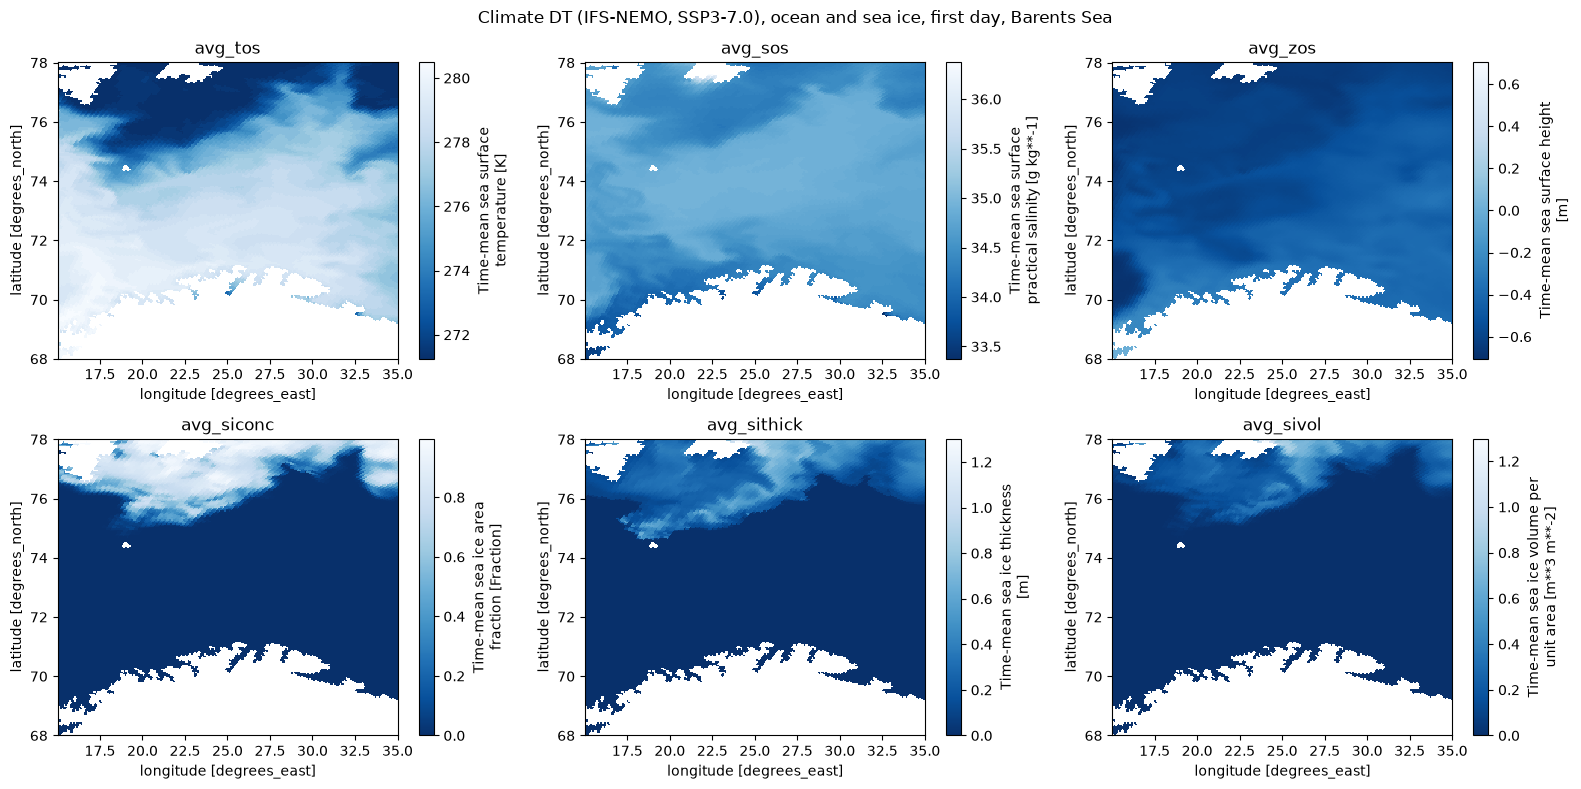

In [ ]:
# bounding box over the Barents Sea: Norwegian coast toward Svalbard
BBOX = {"lat": slice(68.0, 78.0), "lon": slice(15.0, 35.0)}

barents = ds.sel(latitude=BBOX["lat"], longitude=BBOX["lon"])
print(f"Selected window: {barents.sizes['latitude']} x {barents.sizes['longitude']} pixels")

# top row: ocean state; bottom row: the sea ice it produces
VARIABLES = [
    ["avg_tos", "avg_sos", "avg_zos"],
    ["avg_siconc", "avg_sithick", "avg_sivol"],
]

t0 = time.perf_counter()
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for row_axes, row_vars in zip(axes, VARIABLES):
    for ax, name in zip(row_axes, row_vars):
        field = barents[name].isel(time=0).compute()   # download happens here
        field.plot(ax=ax, cmap="Blues_r")
        ax.set_title(name)
plt.suptitle("Climate DT (IFS-NEMO, SSP3-7.0), ocean and sea ice, first day, Barents Sea")
plt.tight_layout()
plt.show()


### A time series: one year of sea ice concentration

`.mean(dim=["latitude", "longitude"])` averages the concentration values of
all pixels in the box, day by day. The two spatial dimensions collapse and
only time remains: a time series, in one line of code.

We pull the first 365 daily steps, one simulated year. The raw time axis is
just day numbers (day 0 is the first simulated day, because of
`decode_times=False`); the plotting cell builds calendar dates from the start
date declared by the STAC item, falling back to day numbers if absent.

Two tips for reading the plot: the ice maximum falls in late winter, months
after the plot starts; and the last day does not need to match the first,
seasonal cycles are not closed loops and each year has its own variability.

Cost: 365 days span 7 time chunks over a few spatial chunks, tens of MB.

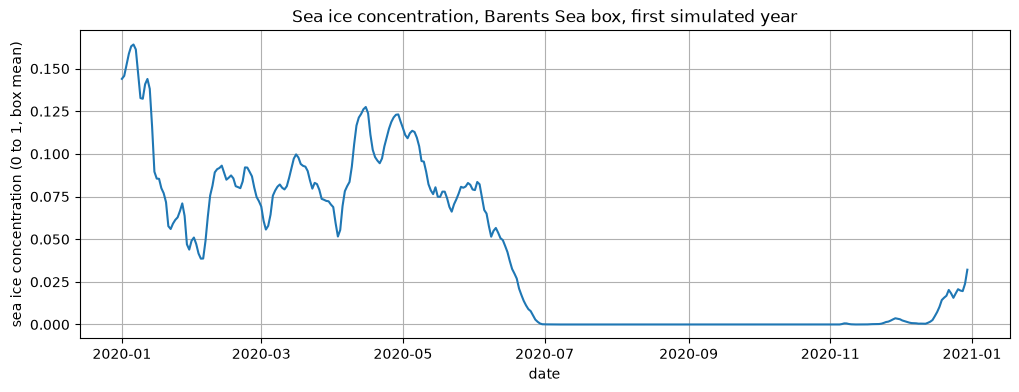

In [ ]:
# one year of daily data: 365 time steps of the box selected above
one_year = barents["avg_siconc"].isel(time=slice(0, 365))

# average the concentration values of all pixels in the box, day by day;
# latitude and longitude collapse, only the time dimension remains
t0 = time.perf_counter()
ice_series = (
    one_year
    .mean(dim=["latitude", "longitude"])   # NaN (land) pixels are skipped
    .compute()                             # the actual download happens here
)

# x axis: calendar dates if the STAC item declares its start date,
# plain day numbers otherwise
start_date = items[0]["properties"].get("start_datetime")
if start_date:
    x = pd.date_range(start=start_date[:10], periods=ice_series.sizes["time"], freq="D")
    x_label = "date"
else:
    x = ice_series["time"]
    x_label = "days since start of simulation"

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(x, ice_series)
ax.set_xlabel(x_label)
ax.set_ylabel("sea ice concentration (0 to 1, box mean)")
ax.set_title("Sea ice concentration, Barents Sea box, first simulated year")
ax.grid(True)
plt.show()

## Summary

This notebook showed that the Climate DT zarr datasets are accessible through
HDA with a single credential and a short recipe: DESP credentials converted
into a DEDL token by `destinelab`, a STAC query to locate the collection and
its zarr asset, and a lazy `xr.open_dataset` call with the Bearer header in
`storage_options`. Chunked lazy access kept the footprint tiny: we analyzed
ocean and sea ice fields over the Barents Sea, maps and a one year time
series, moving only tens of MB out of a multi TB dataset.

**Main finding on availability**: the desp_cache mechanism works end to end,
but the content behind it is still the previous Climate DT release. Only two
of the 40 Digital Twin collections in the HDA catalog expose zarr through
desp_cache (`EO.ECMWF.DAT.DT_CLIMATE_ADAPTATION_IFS-NEMO` and
`EO.ECMWF.DAT.DT_CLIMATE_ADAPTATION_ICON`), serving 6 datasets from that
previous release. **None of the 36 generation 2 datasets published in the
cache is registered in HDA yet**.

Good to know about desp_cache:

* desp_cache is not a service you install or configure: it is the name of the
  data source inside the HDA download service that mirrors the Climate DT
  zarr store. You use it simply by opening the `href` URL of a zarr asset,
  nothing else.
* One credential covers everything: the Bearer token works for the catalog,
  the metadata and the data chunks. There is no separate registration, key or
  quota to manage for this route.
* The route is read only and lazy friendly: select your region and period
  first, call `.compute()` last, and you will move MB instead of TB. The
  chunk arithmetic in the dataset section tells you the cost of any query
  before you run it.
* It works beyond this notebook: any HTTP client that can send the
  `Authorization: Bearer` header (curl, requests, another language) can fetch
  files from the same URLs.

Common problems:

| Symptom | Likely cause | Fix |
|---|---|---|
| 401 on any request | Token expired or absent | Rerun the auth cell |
| 403 | Account lacks `DPAD_Direct_Access` | Request upgraded access on the platform |
| 404 on collection or items | Wrong collection id | Verify the identifier against the HDA collections endpoint |
| 400 on the items query | The collection is order based: items are generated from search constraints, not pre listed | Use the order workflow (see the DataLake Lab notebooks) or one of the two desp_cache collections |
| Kernel hangs on `.compute()` | Slice touches many chunks | Select smaller windows or periods |

## Resources and references

* [DestinE data portfolio](https://platform.destine.eu/destine-data-portfolio/)
* [Climate DT user guide](https://platform.destine.eu/services/documents-and-api/doc/?service_name=climate-dt-user-guide)
* [DestinE DataLake Lab, official DEDL examples](https://github.com/destination-earth/DestinE-DataLake-Lab)
* [destinelab on PyPI](https://pypi.org/project/destinelab/)